<a href="https://colab.research.google.com/github/Mubby03/Machine-Deep-Learning-Pancakes/blob/main/heart_attack_Excercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import pandas as pd
import seaborn as sb
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

In [5]:
diabetes= pd.read_csv('/content/drive/MyDrive/heart_attack.csv')
#load the diabetes.csv file into a pandas DataFrame called diabetes

**Initial Exploration**

In [6]:
diabetes.head(5)

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,HvyAlcoholConsump,MentHlth,PhysHlth,Sex,Age,Education,Income
0,0,1,1,1,40.0,1,0,0,0,0,18,15,0,9,4,3
1,0,0,0,0,25.0,1,0,0,1,0,0,0,0,7,6,1
2,0,1,1,1,28.0,0,0,0,0,0,30,30,0,9,4,8
3,0,1,0,1,27.0,0,0,0,1,0,0,0,0,11,3,6
4,0,1,1,1,24.0,0,0,0,1,0,3,0,0,11,5,4


In [7]:
diabetes.dtypes

,0
HeartDiseaseorAttack,int64
HighBP,int64
HighChol,int64
CholCheck,int64
BMI,float64
Smoker,int64
Stroke,int64
Diabetes,int64
PhysActivity,int64
HvyAlcoholConsump,int64


In [8]:
diabetes.columns

Index(['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'CholCheck', 'BMI',
       'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'HvyAlcoholConsump',
       'MentHlth', 'PhysHlth', 'Sex', 'Age', 'Education', 'Income'],
      dtype='object')

In [9]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129998 entries, 0 to 129997
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HeartDiseaseorAttack  129998 non-null  int64  
 1   HighBP                129998 non-null  int64  
 2   HighChol              129998 non-null  int64  
 3   CholCheck             129998 non-null  int64  
 4   BMI                   129988 non-null  float64
 5   Smoker                129998 non-null  int64  
 6   Stroke                129998 non-null  int64  
 7   Diabetes              129998 non-null  int64  
 8   PhysActivity          129998 non-null  int64  
 9   HvyAlcoholConsump     129998 non-null  int64  
 10  MentHlth              129998 non-null  int64  
 11  PhysHlth              129998 non-null  int64  
 12  Sex                   129998 non-null  int64  
 13  Age                   129998 non-null  int64  
 14  Education             129998 non-null  int64  
 15  

In [10]:
diabetes.describe()

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,HvyAlcoholConsump,MentHlth,PhysHlth,Sex,Age,Education,Income
count,129998.000000,129998.000000,129998.000000,129998.000000,129988.000000,129998.000000,129998.000000,129998.000000,129998.000000,129998.000000,129998.000000,129998.000000,129998.000000,129998.000000,129998.000000,129998.000000
mean,0.093509,0.429614,0.426322,0.963315,28.435586,0.448030,0.041354,0.296689,0.760758,0.057562,3.159718,4.222942,0.439214,8.056624,5.078670,6.098894
std,0.291146,0.495023,0.494544,0.187988,6.999582,0.497294,0.199110,0.697608,0.426622,0.232915,7.344179,8.689544,0.496293,3.048218,0.977537,2.057443
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,0.000000,2.000000,3.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,2.000000,1.000000,1.000000,30.000000,30.000000,1.000000,13.000000,6.000000,8.000000


In [11]:
diabetes.describe().T #Transpose()

,count,mean,std,min,25%,50%,75%,max
HeartDiseaseorAttack,129998.0,0.093509,0.291146,0.0,0.0,0.0,0.0,1.0
HighBP,129998.0,0.429614,0.495023,0.0,0.0,0.0,1.0,1.0
HighChol,129998.0,0.426322,0.494544,0.0,0.0,0.0,1.0,1.0
CholCheck,129998.0,0.963315,0.187988,0.0,1.0,1.0,1.0,1.0
BMI,129988.0,28.435586,6.999582,12.0,24.0,27.0,31.0,98.0
Smoker,129998.0,0.448030,0.497294,0.0,0.0,0.0,1.0,1.0
Stroke,129998.0,0.041354,0.199110,0.0,0.0,0.0,0.0,1.0
Diabetes,129998.0,0.296689,0.697608,0.0,0.0,0.0,0.0,2.0
PhysActivity,129998.0,0.760758,0.426622,0.0,1.0,1.0,1.0,1.0
HvyAlcoholConsump,129998.0,0.057562,0.232915,0.0,0.0,0.0,0.0,1.0


In [12]:
#number of duplicates.
diabetes.duplicated().sum()

np.int64(22961)

In [13]:
# Remove duplicates
diabetes.drop_duplicates(inplace = True)
diabetes.to_csv("/content/drive/MyDrive/heart_attack_clean.csv")

In [14]:
diabetes.isnull().sum()

,0
HeartDiseaseorAttack,0
HighBP,0
HighChol,0
CholCheck,0
BMI,10
Smoker,0
Stroke,0
Diabetes,0
PhysActivity,0
HvyAlcoholConsump,0


Fixing Null DAta.

In [27]:
# More overview of features
diabetes.describe(include = "all").T

,count,mean,std,min,25%,50%,75%,max
HeartDiseaseorAttack,106765.0,0.110898,0.314007,0.0,0.0,0.0,0.0,1.0
HighBP,106765.0,0.470800,0.499149,0.0,0.0,0.0,1.0,1.0
HighChol,106765.0,0.453416,0.497828,0.0,0.0,0.0,1.0,1.0
CholCheck,106765.0,0.957495,0.201738,0.0,1.0,1.0,1.0,1.0
BMI,106765.0,28.829335,6.851642,12.0,24.0,28.0,32.0,79.0
Smoker,106765.0,0.483304,0.499724,0.0,0.0,0.0,1.0,1.0
Stroke,106765.0,0.050082,0.218115,0.0,0.0,0.0,0.0,1.0
Diabetes,106765.0,0.352025,0.746688,0.0,0.0,0.0,0.0,2.0
PhysActivity,106765.0,0.718691,0.449640,0.0,0.0,1.0,1.0,1.0
HvyAlcoholConsump,106765.0,0.066604,0.249336,0.0,0.0,0.0,0.0,1.0


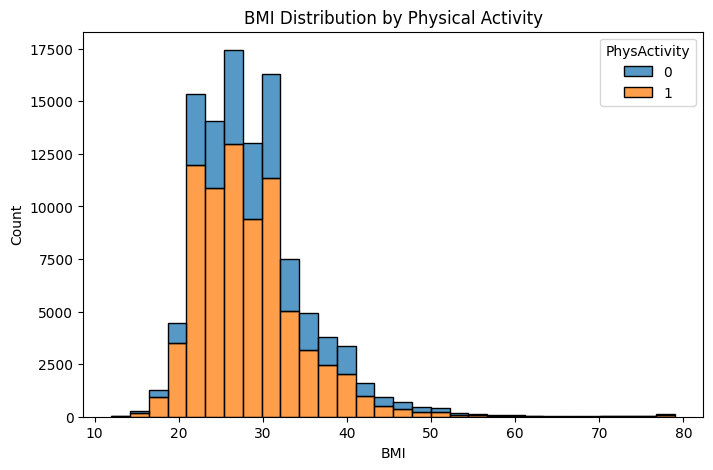

In [28]:
# Remove null BMI values
diabetes = diabetes.dropna(subset=["BMI"])

# Remove unrealistic BMI values (0 or extremely high)
diabetes = diabetes[(diabetes["BMI"] > 9) & (diabetes["BMI"] < 80)]

# Plot histogram
plt.figure(figsize=(8,5))
sns.histplot(data=diabetes, x="BMI", hue="PhysActivity", bins=30, multiple="stack")

plt.title("BMI Distribution by Physical Activity")
plt.xlabel("BMI")
plt.ylabel("Count")

plt.show()


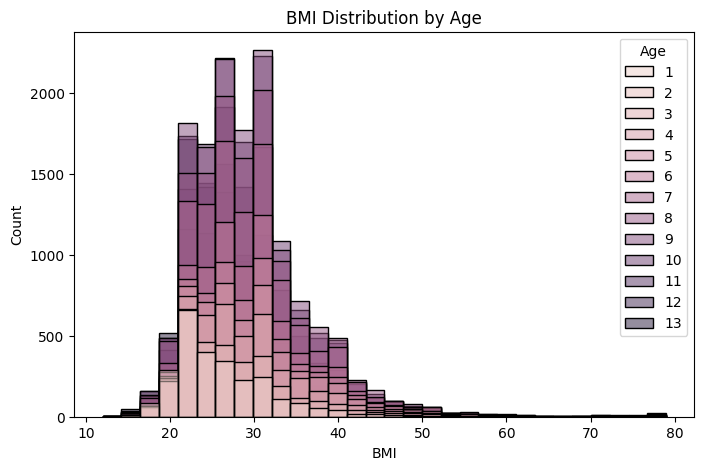

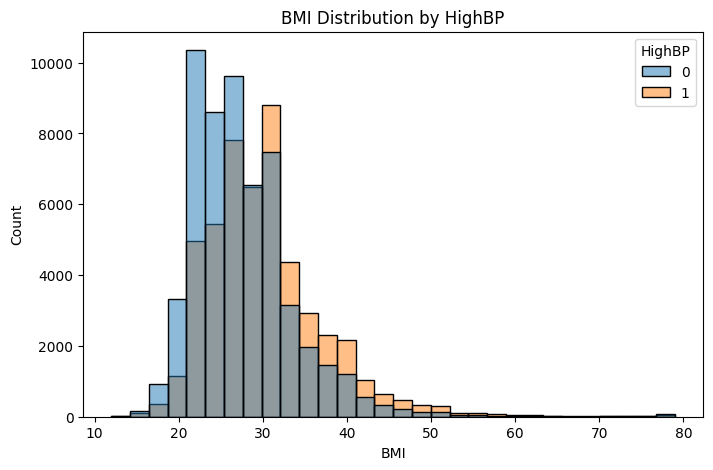

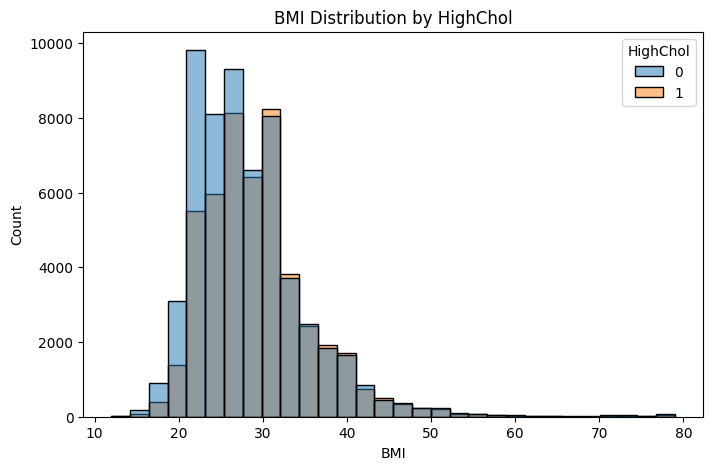

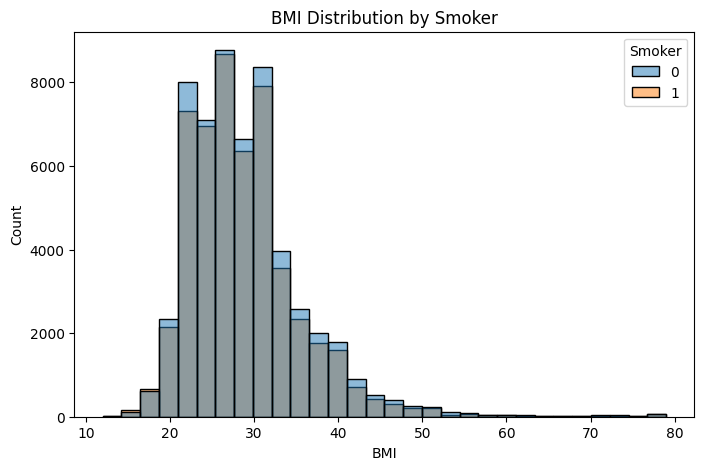

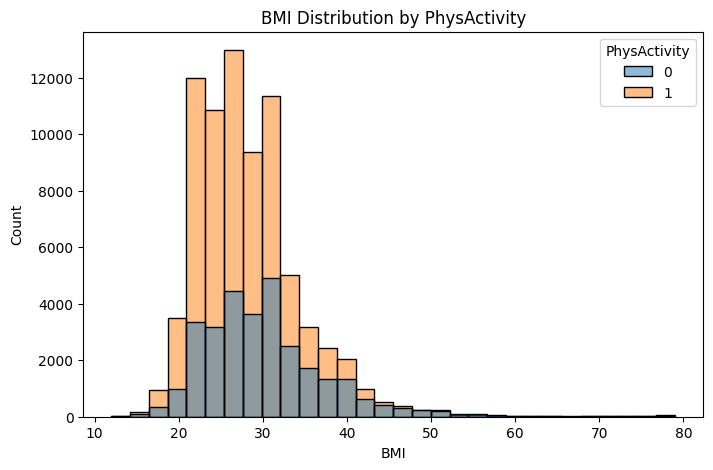

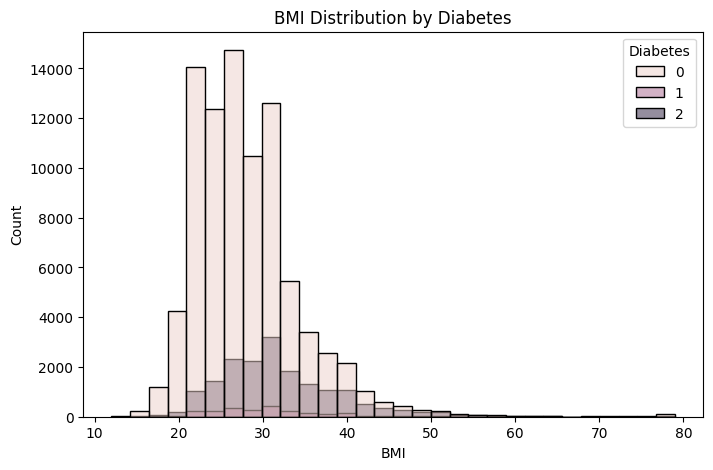

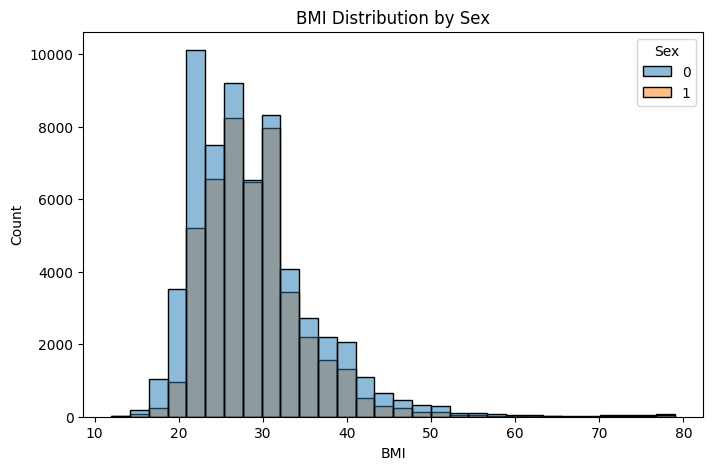

In [30]:
features = ["Age","HighBP","HighChol","Smoker","PhysActivity","Diabetes","Sex"]

for f in features:
    plt.figure(figsize=(8,5))
    sns.histplot(data=diabetes, x="BMI", hue=f, bins=30)
    plt.title(f"BMI Distribution by {f}")
    plt.show()